# image-quality forensics



In [30]:
# ---------------------------------------------------------------------------
# Batch eval — on-device (eval-server, production-accurate)
#
# Prerequisites:
#   1. Build with eval mode:
#        cd mobile && ./scripts/dev_deploy.sh --eval
#        then Xcode → Product → Run  (confirm "Eval mode: HTTP server on :8080" in console)
#   2. USB tunnel (keep running in a separate terminal):
#        iproxy 8080 8080
#   3. Health check:
#        curl http://127.0.0.1:8080/health   # should return {"status":"ok",...}
#
# The --backend eval-server path uses ML Kit OCR → Gemma 4 E2B (on-device GGUF),
# matching production exactly. ocr_chars is written to eval_runs.csv.
#
# For quick off-device runs (vision LLM, NOT production-accurate):
#   --backend ollama   (requires: ollama serve  with  gemma4 pulled)
# ---------------------------------------------------------------------------

from pathlib import Path

PHOTOS_DIR = "/Users/danfinkel/github/civics/research/eval/results/synthetic_validation/variants/distance"
PHONE_IP   = "127.0.0.1"   # USB tunnel; change to LAN IP for Wi-Fi
RUNS       = 2
COOLDOWN   = 5             # seconds between runs on the same photo
PHOTO_BREAK = 15           # seconds between photos (thermal)
RESULT_FOLDER = "zoom_testing"
RESULTS_DIR = Path("/Users/danfinkel/github/civics/research/eval/results/" + RESULT_FOLDER)

! python3 real_photo_characterizer.py \
    --photos {PHOTOS_DIR} \
    --out results/{RESULT_FOLDER} \
    --backend eval-server \
    --phone-ip {PHONE_IP} \
    --runs-per-photo {RUNS} \
    --cooldown {COOLDOWN} \
    --photo-break {PHOTO_BREAK}


Checking eval server at http://127.0.0.1:8080 … ok (gemma4-e2b)
Photo 1/27: distance_cluttered_0.15.jpg → attributes extracted → inference: 2/2 runs → label: fail (0/2 deadline exact)
Photo 2/27: distance_cluttered_0.20.jpg → attributes extracted → inference: 2/2 runs → label: fail (0/2 deadline exact)
Photo 3/27: distance_cluttered_0.25.jpg → attributes extracted → inference: 2/2 runs → label: fail (0/2 deadline exact)
Photo 4/27: distance_cluttered_0.35.jpg → attributes extracted → inference: 2/2 runs → label: fail (0/2 deadline exact)
Photo 5/27: distance_cluttered_0.45.jpg → attributes extracted → inference: 2/2 runs → label: pass (2/2 deadline exact)
Photo 6/27: distance_cluttered_0.55.jpg → attributes extracted → inference: 2/2 runs → label: pass (2/2 deadline exact)
Photo 7/27: distance_cluttered_0.70.jpg → attributes extracted → inference: 2/2 runs → label: pass (2/2 deadline exact)
Photo 8/27: distance_cluttered_0.85.jpg → attributes extracted → inference: 2/2 runs → label: pa

In [11]:
RESULT_DIR = Path("/Users/danfinkel/github/civics/research/eval/results/zoom_testing")

## Additional Performance Analysis

In [31]:
# load raw results
import pandas as pd
df = pd.read_csv("/Users/danfinkel/github/civics/research/eval/results/zoom_testing/eval_runs.csv")
df.head()
# bool_cols = df.select_dtypes(include='bool').columns.tolist()
# df[['filename'] + bool_cols].groupby('filename').agg('sum').sum()


,filename,run,critical_deadline_exact,notice_deadline,notice_deadline_chars,ocr_chars,response_deadline_correct_field,response_deadline_label,response_deadline_score
0,distance_cluttered_0.15.jpg,0,False,NaN,0,5,True,missing,0.0
1,distance_cluttered_0.15.jpg,1,False,NaN,0,5,True,missing,0.0
2,distance_cluttered_0.20.jpg,0,False,NaN,0,33,True,missing,0.0
3,distance_cluttered_0.20.jpg,1,False,NaN,0,33,True,missing,0.0
4,distance_cluttered_0.25.jpg,0,False,NaN,0,148,True,missing,0.0


## Examine Bad Images


13


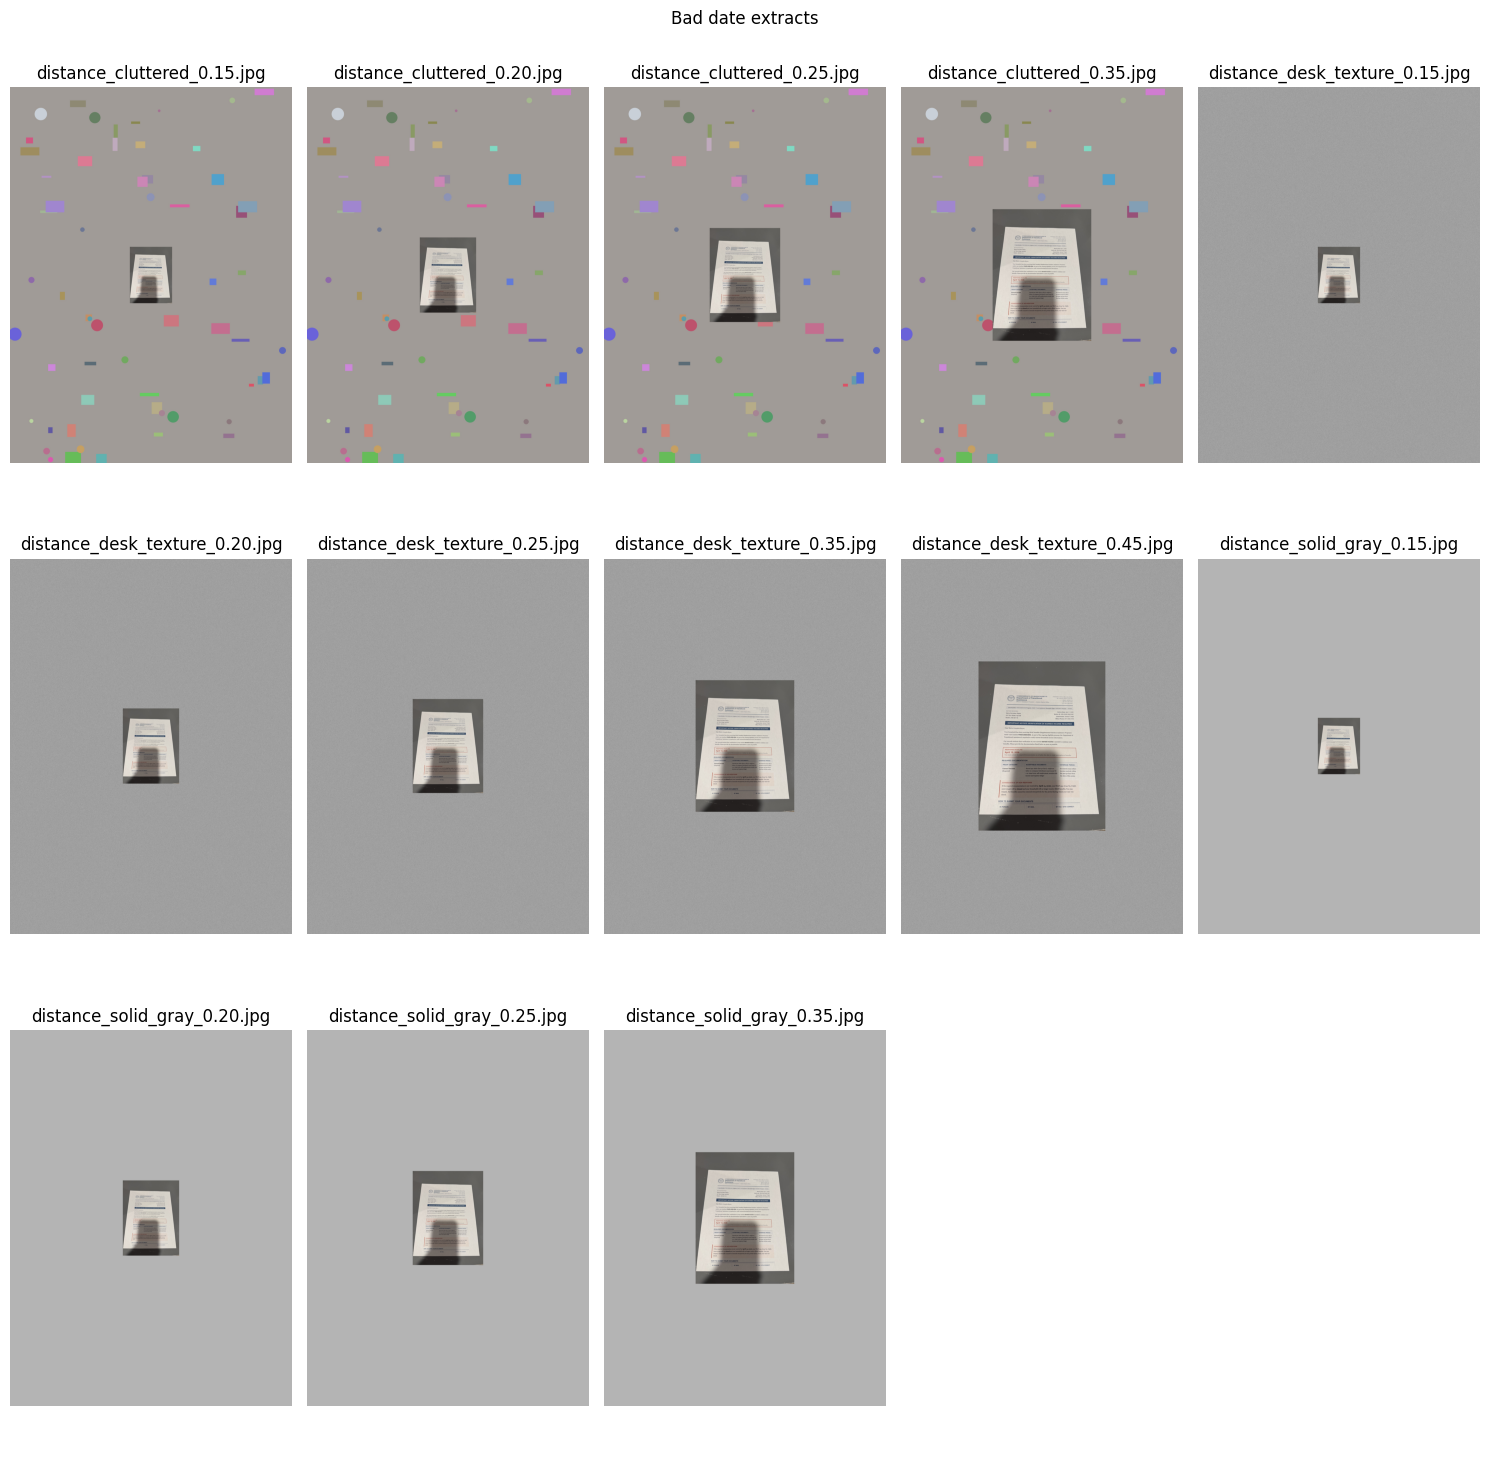

In [32]:
from matplotlib import image as mpimg
import matplotlib.pyplot as plt

fnames = df.query("critical_deadline_exact == False").filename.unique()
print(len(fnames))
n = len(fnames)
if n == 0:
    print("No rows with critical_deadline_exact == False")
else:
    fig, ax = plt.subplots(3, 5, figsize=(15, 15))
    for i, fname in enumerate(fnames):
        fpath = Path(PHOTOS_DIR)
        p = fpath / fname
        im = mpimg.imread(p)
        ax[i//5, i%5].imshow(im)
        ax[i//5, i%5].set_axis_off()
        ax[i//5, i%5].set_title(fname)
    for ii in range(i, 15):
        ax[ii//5, ii%5].set_axis_off()
    fig.suptitle("Bad date extracts")
    plt.tight_layout()
    plt.show()

In [33]:
fnames

<StringArray>
[   'distance_cluttered_0.15.jpg',    'distance_cluttered_0.20.jpg',
    'distance_cluttered_0.25.jpg',    'distance_cluttered_0.35.jpg',
 'distance_desk_texture_0.15.jpg', 'distance_desk_texture_0.20.jpg',
 'distance_desk_texture_0.25.jpg', 'distance_desk_texture_0.35.jpg',
 'distance_desk_texture_0.45.jpg',   'distance_solid_gray_0.15.jpg',
   'distance_solid_gray_0.20.jpg',   'distance_solid_gray_0.25.jpg',
   'distance_solid_gray_0.35.jpg']
Length: 13, dtype: str

## Examine Good Images

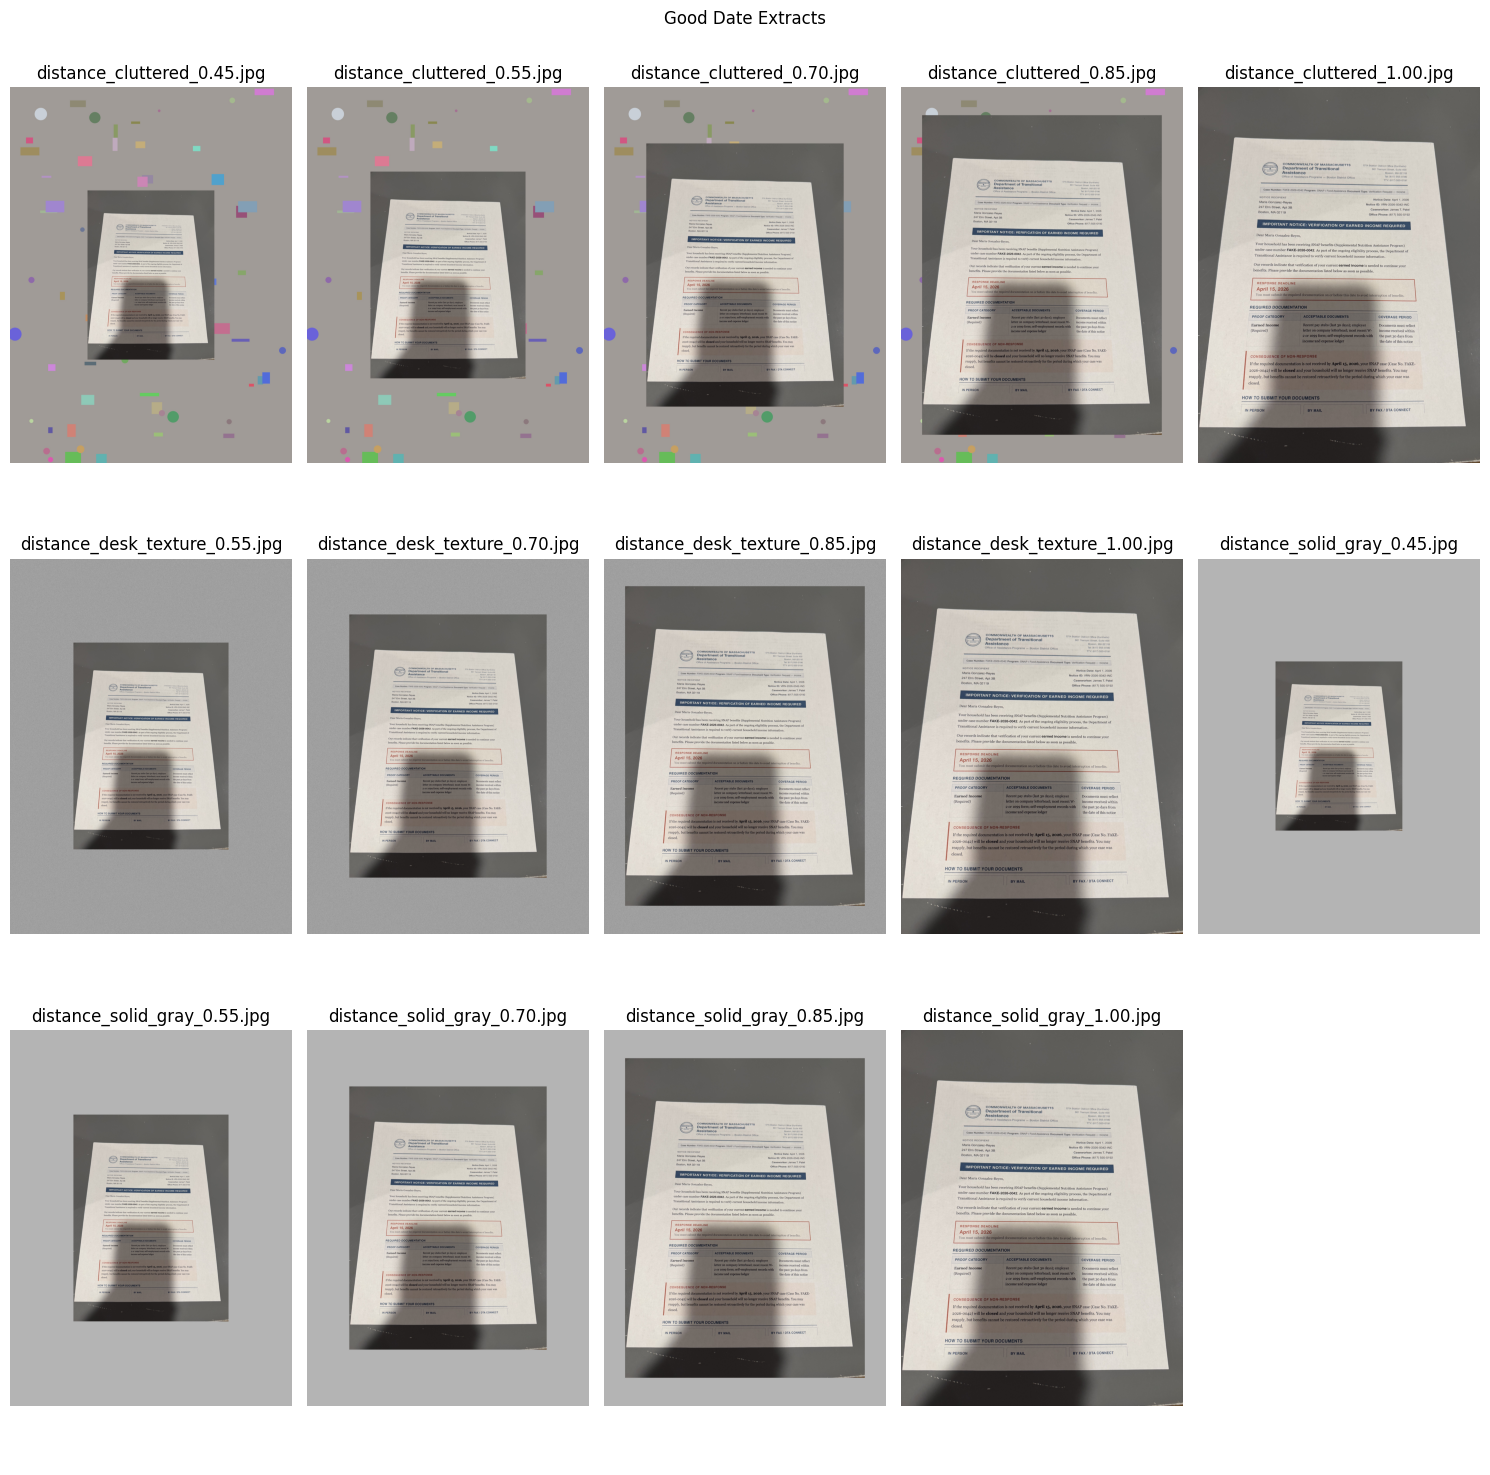

In [34]:
fnames = df.query('critical_deadline_exact == True').filename.unique()
img_path = "/Users/danfinkel/github/research/eval/results/real_photo_analysis/converted/"
fig, ax = plt.subplots(3, 5, figsize=(15, 15))
for i, fname in enumerate(fnames):
    p = fpath / fname
    im = mpimg.imread(p)
    # print(i//4, i%8)
    ax[i//5, i%5].imshow(im)
    ax[i//5, i%5].set_axis_off()
    ax[i//5, i%5].set_title(fname)
for ii in range(i, 15):
    ax[ii//5, ii%5].set_axis_off()    
fig.suptitle('Good Date Extracts')
plt.tight_layout()
plt.show()

## Single-photo probe (manual examination)


Requires earlier setup cells (**`RESULT_DIR`** / **`_find_eval_dir`** from § imports).

Set **`PHOTO_PATH`** to any supported file (`.jpg`, `.jpeg`, `.heic`). Requires the same setup as batch eval: **Ollama** at `localhost:11434` for `backend="ollama"`, or an **eval phone** with `PHONE_IP` / `phone_ip` for `backend="eval_server"`. 
**Ollama with `EMULATE_DEVICE_INFER`:** still uses **`ollama serve` on localhost** (text `/api/chat`); use **`BACKEND="eval_server"`** to hit real on-device GGUF.

**Vision vs. on-device fidelity:** Default **Ollama** here sends **pixels** (`images[]`), while the eval phone path is **text-only**: ML Kit OCR is appended and the prompt is **char-clamped** (5600) with **bounded output tokens** (~2048). Enable **`EMULATE_DEVICE_INFER`** below to replay that pipeline with Tesseract + `call_ollama_text_only` (OCR text will not match ML Kit exactly).

Pixel attributes are printed as a one-row table; the vision model response is the full raw text plus parsed JSON and per-field scores (same pipeline as `eval_runs.csv`).


In [ ]:
from pathlib import Path
import json
import pprint
import sys
import time

import pandas as pd
from IPython.display import Image, display


def _find_eval_dir() -> Path:
    """Directory containing `real_photo_characterizer.py` (usually `research/eval`)."""
    cwd = Path.cwd().resolve()
    if (cwd / "real_photo_characterizer.py").is_file():
        return cwd
    for sub in (cwd / "research" / "eval",):
        if (sub / "real_photo_characterizer.py").is_file():
            return sub
    for anc in (cwd, *cwd.parents):
        d = anc / "research" / "eval"
        if (d / "real_photo_characterizer.py").is_file():
            return d
    return cwd


def _find_photo_attributes_csv() -> Path:
    """Prefer `results/blur_testing/`, then legacy `real_photo_analysis/`."""
    ev = _find_eval_dir()
    for sub in ("blur_testing", "real_photo_analysis"):
        p = ev / "results" / sub / "photo_attributes.csv"
        if p.is_file():
            return p
    raise FileNotFoundError(
        f"Could not find photo_attributes.csv in {ev}/results/blur_testing/ or "
        f".../real_photo_analysis/. Run: python3 real_photo_characterizer.py ... "
        f"--out results/blur_testing --backend ollama (cwd={Path.cwd()})"
    )


CSV = _find_photo_attributes_csv()
RESULT_DIR = CSV.parent

# --- edit these ---
PHOTO_PATH = Path(
    "/Users/danfinkel/github/research/eval/results/real_photo_analysis/converted/IMG_9069.jpg"
)
BACKEND = "eval_server"  # "ollama" | "eval_server"

# eval_server only — which endpoint to hit:
#   "track_a"   → /infer_track_a  (production-accurate: analyzeTrackAWithOcr +
#                  trackAOcrOnly prompt + 2048 tokens). Use this for eval that
#                  matches the real app. Displays notice_summary JSON.
#   "infer_raw" → /infer  (D01_SEMANTIC_PROMPT, flat JSON, useful for ablation
#                  comparison with the off-device Ollama path).
BACKEND_MODE = "track_a"  # "track_a" | "infer_raw"

# Tesseract OCR + device-shaped prompt → Ollama *text-only* (/api/chat, no images).
# **Requires `ollama serve` on localhost** — emulation does NOT replace local Ollama.
EMULATE_DEVICE_INFER = True
# "infer_raw" = eval /infer default OCR blob; "track_a_notice_cap" = 2000-char notice truncation line
DEVICE_OCR_MODE = "infer_raw"
# Request the raw ML Kit OCR text from the eval server alongside the LLM response.
# Only applies when BACKEND="eval_server" and BACKEND_MODE="infer_raw".
INCLUDE_OCR_DIAG = True

N_RUNS = 1
# Host only, or host:port — do not duplicate the port (8080 is appended if omitted).
# USB (iproxy 8080 8080): use "127.0.0.1" or "127.0.0.1:8080" (both work).
PHONE_IP = "127.0.0.1"
OLLAMA_MAX_LONG_EDGE = 1024
OLLAMA_TIMEOUT_S = 600.0
OLLAMA_TEMPERATURE = 0.0
OLLAMA_DEVICE_NUM_PREDICT = 2048
COOLDOWN_S = 3.0
# ------------------

EVAL = _find_eval_dir()
if str(EVAL) not in sys.path:
    sys.path.insert(0, str(EVAL))

import real_photo_characterizer as rpc
from runner import (
    eval_server_preflight,
    load_ground_truth,
    parse_with_retry,
    run_inference as runner_run_inference,
    run_inference_track_a,
    score_track_a_production,
)

from device_eval_mirror import (
    DEFAULT_DEVICE_OUTPUT_MAX_TOKENS,
    finalize_device_style_prompt,
    ocr_image_tesseract,
)

photo = PHOTO_PATH.expanduser().resolve()
if not photo.is_file():
    raise FileNotFoundError(photo)

probe_dir = RESULT_DIR / "single_probe"
jpeg_path = rpc.ensure_jpeg(photo, probe_dir)
print("Working JPEG:", jpeg_path)

attrs = rpc.extract_attributes(jpeg_path)
print("\n--- Pixel attributes ---")
display(pd.DataFrame([attrs]))

gt = load_ground_truth()

runs: list[dict] = []


def _require_ollama() -> None:
    if rpc.ollama_available():
        return
    raise RuntimeError(
        "Ollama is not reachable at http://127.0.0.1:11434 (GET /api/tags failed). "
        "Start locally: run `ollama serve` in a terminal, then re-run this cell.\n\n"
        "Important: EMULATE_DEVICE_INFER still sends requests to **this same Ollama** — it switches "
        "from vision (`images`) to **text-only** chat with num_predict (~on-device decode cap). "
        "To hit the actual phone GGUF stack, use BACKEND=\"eval_server\".\n\n"
        "Tunnel / remote hosts: notebook uses rpc.OLLAMA_BASE in real_photo_characterizer.py "
        "(default 127.0.0.1:11434); change there or rerun after `ollama serve` is listening."
    )


if BACKEND == "eval_server":
    phone_url = rpc.eval_server_url(PHONE_IP)
    if not phone_url:
        raise RuntimeError(
            "eval_server requires PHONE_IP to be set (e.g. PHONE_IP = '192.168.1.x')"
        )
    image_b64 = __import__("base64").b64encode(jpeg_path.read_bytes()).decode("ascii")
    eval_server_preflight(phone_url)

    if BACKEND_MODE == "track_a":
        # Production-accurate path: calls analyzeTrackAWithOcr on device.
        # Same prompt (trackAOcrOnly), same OCR formatter (_formatOcrResultsTrackA),
        # same token budget (2048) as the production app.
        print(f"\n[probe] mode=track_a → POST {phone_url}/infer_track_a\n")
        for i in range(N_RUNS):
            if i > 0:
                time.sleep(COOLDOWN_S)
            result = run_inference_track_a(
                phone_url,
                image_b64,
                supporting_labels=[],
                timeout=int(OLLAMA_TIMEOUT_S),
            )
            if result.get("error"):
                print(f"[run {i}] ERROR: {result['error']}")

            notice_summary = result.get("notice_summary") or {}
            notice_deadline = result.get("notice_deadline", "")
            ocr_chars = result.get("ocr_chars", 0)

            print(f"\n{'='*72}")
            print(f"  ML Kit OCR char count: {ocr_chars}")
            print(f"{'='*72}")
            print("\n--- notice_summary (production schema) ---\n")
            print(json.dumps(notice_summary, indent=2, default=str))
            if result.get("action_summary"):
                print("\n--- action_summary ---\n")
                print(result["action_summary"])
            if result.get("proof_pack"):
                print("\n--- proof_pack ---\n")
                pprint.pp(result["proof_pack"], width=120, compact=True)

            crit = score_track_a_production(result, "D01", gt)
            print(f"\n--- Scoring (notice_summary.deadline vs GT response_deadline) ---\n")
            pprint.pp(crit, width=120, compact=True)

            runs.append(
                {
                    "run": i,
                    "raw_response": result.get("response", ""),
                    "parsed": notice_summary,
                    "scores": {
                        "response_deadline": {
                            "label": crit["critical_label"],
                            "score": crit["critical_score"],
                            "correct_field": crit["critical_label"] not in ("misattribution", "hallucinated"),
                        }
                    },
                    "critical_deadline_exact": crit["critical_label"] == "exact",
                    "notice_summary": notice_summary,
                    "notice_deadline": notice_deadline,
                    "ocr_chars": ocr_chars,
                }
            )

    else:
        # infer_raw path: D01_SEMANTIC_PROMPT + flat JSON schema (ablation / comparison).
        print(f"\n[probe] mode=infer_raw → POST {phone_url}/infer\n")
        for i in range(N_RUNS):
            if i > 0:
                time.sleep(COOLDOWN_S)
            result = runner_run_inference(
                phone_url,
                image_b64,
                rpc.D01_SEMANTIC_PROMPT,
                track="a",
                temperature=OLLAMA_TEMPERATURE,
                timeout=int(OLLAMA_TIMEOUT_S),
                include_ocr_diag=INCLUDE_OCR_DIAG,
            )
            if result.get("error"):
                print(f"[run {i}] ERROR: {result['error']}")
            ocr_text_device = result.get("ocr_text") or ""
            if INCLUDE_OCR_DIAG and ocr_text_device:
                print(f"\n{'='*72}")
                print(f"  ML Kit OCR output ({len(ocr_text_device)} chars) — raw from device")
                print(f"{'='*72}")
                print(ocr_text_device[:2000] + ("…" if len(ocr_text_device) > 2000 else ""))
                print(f"{'='*72}")
                print(
                    f"OCR elapsed: {result.get('ocr_elapsed_ms')} ms  |  "
                    f"LLM elapsed: {result.get('llm_elapsed_ms')} ms"
                )
            elif INCLUDE_OCR_DIAG:
                print("\n[OCR diag] No OCR text returned — check that the rebuilt app is running.")
            raw = result.get("response", "")
            parsed = parse_with_retry(raw)
            scored = rpc.score_against_ground_truth("D01", parsed, gt)
            rd = scored.get("response_deadline") or {}
            runs.append(
                {
                    "run": i,
                    "raw_response": raw,
                    "parsed": parsed,
                    "scores": scored,
                    "critical_deadline_exact": rd.get("label") == "exact",
                }
            )

elif BACKEND == "ollama" and EMULATE_DEVICE_INFER:
    try:
        ocr_text = ocr_image_tesseract(jpeg_path)
    except ImportError as e:
        raise RuntimeError(
            "Install OCR deps: pip install pytesseract pillow  (plus: brew install tesseract)"
        ) from e
    print(f"\n--- Tesseract OCR ({len(ocr_text)} chars) — first 400 chars ---\n")
    print((ocr_text[:400] + "…") if len(ocr_text) > 400 else ocr_text)
    fprompt = finalize_device_style_prompt(
        rpc.D01_SEMANTIC_PROMPT,
        ocr_text,
        ocr_mode=DEVICE_OCR_MODE,
    )
    print(
        f"\n--- Device-style prompt: {len(fprompt)} chars after clamp "
        f"(bounded decode ≈ Ollama num_predict={OLLAMA_DEVICE_NUM_PREDICT}; "
        f"mobile isolate default decode cap ≈ {DEFAULT_DEVICE_OUTPUT_MAX_TOKENS})\n"
    )
    markers = []
    if "[... text truncated for model limits ...]" in fprompt:
        markers.append("OCR-per-section truncation marker present")
    if "[Body truncated for on-device limits.]" in fprompt or "\n\n[Truncated]" in fprompt:
        markers.append("prompt-level clamp truncation")
    if markers:
        print("Clamp / OCR markers detected:", "; ".join(markers))

    _require_ollama()
    for i in range(N_RUNS):
        if i > 0:
            time.sleep(COOLDOWN_S)
        raw = rpc.call_ollama_text_only(
            fprompt,
            temperature=OLLAMA_TEMPERATURE,
            timeout_s=OLLAMA_TIMEOUT_S,
            num_predict=OLLAMA_DEVICE_NUM_PREDICT,
        )
        parsed = parse_with_retry(raw)
        scored = rpc.score_against_ground_truth("D01", parsed, gt)
        rd = scored.get("response_deadline") or {}
        runs.append(
            {
                "run": i,
                "raw_response": raw,
                "parsed": parsed,
                "scores": scored,
                "critical_deadline_exact": rd.get("label") == "exact",
            }
        )
else:
    assert BACKEND == "ollama"
    _require_ollama()
    runs = rpc.run_extraction(
        jpeg_path,
        backend=BACKEND,
        phone_ip=PHONE_IP,
        gt=gt,
        n_runs=N_RUNS,
        cooldown=COOLDOWN_S,
        ollama_max_long_edge=OLLAMA_MAX_LONG_EDGE,
        ollama_timeout_s=OLLAMA_TIMEOUT_S,
        ollama_temperature=OLLAMA_TEMPERATURE,
    )

for r in runs:
    print("\n" + "=" * 72)
    print("Run", r["run"], "| critical_deadline_exact:", r["critical_deadline_exact"])
    print("=" * 72)
    print("\n--- Raw model response ---\n")
    print(r.get("raw_response") or "(empty)")
    if BACKEND == "eval_server" and BACKEND_MODE == "track_a":
        print("\n--- notice_summary (production schema) ---\n")
        print(json.dumps(r.get("notice_summary") or r.get("parsed"), indent=2, default=str))
    else:
        print("\n--- Parsed JSON ---\n")
        print(json.dumps(r.get("parsed"), indent=2, default=str))
    print("\n--- Field scores (ground-truth rubric) ---\n")
    pprint.pp(r.get("scores"), width=120, compact=True)

display(Image(filename=str(jpeg_path)))
